In [5]:
using CovidSim_ilm

In [6]:
cs = CovidSim_ilm

CovidSim_ilm

In [7]:
using StatsBase
using TypedTables
using BenchmarkTools
export @ballocated, @belapsed, @benchmark, @benchmarkable, @benchmarkset, @bprofile, @btime, @case, @tagged, BenchmarkGroup, BenchmarkTools, addgroup!, allocs, gctime, improvements, invariants, isimprovement, isinvariant, isregression, judge, leaves, loadparams!, mean, median, memory, params, ratio, regressions, rmskew, rmskew!, trim, tune!, warmup
using Distributions
using YAML
using PrettyPrint
using OrderedCollections
using Revise
Revise.revise()
using LinearAlgebra

In [8]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/source"))

# Test setup and population matrix

In [9]:
ndays = 180
locale = 38015
model = buildsim(ndays, locale;  
    dovax = true,
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantfilename = "variants.yml",
);

In [10]:
keys(model)

(:ndays, :locales, :dat, :series, :geo, :transitionset, :vaxset, :vaxschedset, :infectset, :social, :trvec)

### Data tables

In [11]:
locdat = model.dat["popdat"][locale]

Table with 18 columns and 95626 rows:
      pid  status     agegrp   cond        duration  variant  recovday  ⋯
    ┌───────────────────────────────────────────────────────────────────
 1  │ 1    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 2  │ 2    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 3  │ 3    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 4  │ 4    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 5  │ 5    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 6  │ 6    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 7  │ 7    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 8  │ 8    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 9  │ 9    unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 10 │ 10   unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 11 │ 11   unexposed  age0_19  uninfected  0        [:none]  [0]       ⋯
 12 │ 12   u

In [8]:
ages = model.dat["agegrp_idx"][locale]

Dict{agegrp, Vector{Int64}} with 5 entries:
  age20_39 => [24003, 24004, 24005, 24006, 24007, 24008, 24009, 24010, 24011, 2…
  age40_59 => [49918, 49919, 49920, 49921, 49922, 49923, 49924, 49925, 49926, 4…
  age60_79 => [74303, 74304, 74305, 74306, 74307, 74308, 74309, 74310, 74311, 7…
  age80_up => [91898, 91899, 91900, 91901, 91902, 91903, 91904, 91905, 91906, 9…
  age0_19  => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  23993, 23994, 23995, 23996, 23…

In [12]:
columnnames(locdat)

(:pid, :status, :agegrp, :cond, :duration, :variant, :recovday, :deadday, :cluster, :sdcomply, :vaxstatus, :vaxrcvd, :vaxday, :fullvaxday, :tested, :testday, :quar, :quarday)

In [13]:
p = 50_000

50000

In [32]:
getproperty(locdat, :status)

95626-element Vector{status}:
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 ⋮
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1
 unexposed::status = 1

In [35]:
function getcols(tt, p, col1, col2, col3, col4, col5, col6)
    return getproperty(tt, col1)[p], getproperty(tt, col2)[p], getproperty(tt, col3)[p], getproperty(tt, col4)[p],getproperty(tt, col5)[p], getproperty(tt, col6)[p]
end

getcols (generic function with 1 method)

In [47]:
@btime getcols(locdat, p, :status, :cond, :variant, :vaxstatus, :vaxrcvd, :vaxday)

  337.294 ns (15 allocations: 1.11 KiB)


(unexposed, uninfected, [:none], :none, [:none], [0])

In [49]:
@btime pstat, pcond, pvar, pvaxstatus, pvaxrcvd, pvaxday = ans

  444.025 ns (16 allocations: 544 bytes)


(unexposed, uninfected, [:none], :none, [:none], [0])

In [46]:
pstat

unexposed::status = 1

In [24]:
p_status

LoadError: UndefVarError: p_status not defined

In [16]:
@btime locdat[p]

  1.100 μs (27 allocations: 1.19 KiB)


(pid = 50000, status = unexposed, agegrp = age40_59, cond = uninfected, duration = 0, variant = [:none], recovday = [0], deadday = 0, cluster = 0, sdcomply = :none, vaxstatus = :none, vaxrcvd = [:none], vaxday = [0], fullvaxday = 0, tested = false, testday = 0, quar = false, quarday = 0)

In [50]:

@btime begin
    selcol = @Select(status, cond, variant,vaxstatus,vaxrcvd, vaxday)
    newt = selcol.(locdat)
    (pstat,pcond,pvar,pvaxstatus,pvaxrcvd, pvaxday) = newt[p]
end

  603.697 ns (20 allocations: 880 bytes)


(status = unexposed, cond = uninfected, variant = [:none], vaxstatus = :none, vaxrcvd = [:none], vaxday = [0])

In [53]:
@btime newrow = selcol.(locdat)[p]

  146.279 ns (4 allocations: 336 bytes)


(status = unexposed, cond = uninfected, variant = [:none], vaxstatus = :none, vaxrcvd = [:none], vaxday = [0])

In [54]:
@btime newrow.status

  33.115 ns (2 allocations: 64 bytes)


unexposed::status = 1

In [19]:
row

(status = unexposed, cond = uninfected, variant = [:none], vaxstatus = :none, vaxrcvd = [:none], vaxday = [0])

In [ ]:
countmap(locdat.agegrp)

In [ ]:
countmap(locdat.status)  # everyone begins as unexposed

### Social Parameters

In [8]:
fieldnames(typeof(model.social))

(:gammashape, :contactfactors, :touchfactors)

In [ ]:
typeof(model.social.gammashape)

In [ ]:
model.social.contactfactors

In [ ]:
model.social.contactfactors[Int(sick)-4, Int(age0_19)]

In [ ]:
touchfactors = model.social.touchfactors

### Parameters for infection based on variant

In [9]:
fieldnames(typeof(model.infectset[:omicron]))

(:sendrisk, :recvrisk, :recovery_immunity, :immunehalflife, :basemultiplier)

In [10]:
model.infectset

LittleDict{Symbol, Infectparams, Vector{Symbol}, Vector{Infectparams}} with 4 entries:
  :alpha   => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, …
  :base    => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, …
  :omicron => Infectparams([0.0, 0.445, 0.975, 1.125, 1.275, 1.275, 1.125, 1.05…
  :delta   => Infectparams([0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, …

In [12]:
pprintln(model.infectset)

{
  :alpha : Infectparams(
             sendrisk=[0.0, 0.3, 
                       0.65, 0.75, 
                       0.85, 0.85, 
                       0.75, 0.7, 
                       0.65, 0.6, 
                       0.5, 0.2, 
                       0.1, 0.1, 
                       0.1, 0.05, 
                       0.05, 0.0, 
                       0.0, 0.0, 
                       0.0, 0.0, 
                       0.0, 0.0, 
                       0.0],
             recvrisk=[0.12, 0.46799999999999997, 
                       0.528, 0.648, 
                       0.672],
             recovery_immunity={:alpha : 0.8, 
                                :base : 0.8, 
                                :omicron : 0.5, 
                                :delta : 0.7, 
                                :immunestrength : 0.6},
             immunehalflife=240,
             basemultiplier=1.2,
           ),
  :base : Infectparams(
            sendrisk=[0.0, 0.3, 0.65, 
                    

In [11]:
pprintln(model.infectset[:base])

Infectparams(
  sendrisk=[0.0, 0.3, 0.65, 0.75, 
            0.85, 0.85, 0.75, 0.7, 
            0.65, 0.6, 0.5, 0.2, 
            0.1, 0.1, 0.1, 0.05, 
            0.05, 0.0, 0.0, 0.0, 
            0.0, 0.0, 0.0, 0.0, 0.0],
  recvrisk=[0.1, 0.39, 0.44, 0.54, 
            0.56],
  recovery_immunity={:alpha : 0.8, 
                     :base : 0.8, 
                     :omicron : 0.5, 
                     :delta : 0.7},
  immunehalflife=240,
  basemultiplier=1.0,
)


In [ ]:
sendbase = model.infectset[:base].sendrisk
recvbase = model.infectset[:base].recvrisk

In [ ]:
newomisend = zeros(25)
newomisend[1:11] = 1.5 .* sendbase[1:11]
newomisend

In [ ]:
pprint(model.infectset[:alpha])

In [ ]:
pprintln(model.infectset[:omicron])

In [ ]:
# is shifter working?
shifter(touchfactors, (.18, .3)...)[:, Int(age40_59)]

In [ ]:
model.transitionset # the decision transition matrices for all age groups are loaded

In [ ]:
basetransition = model.transitionset[:base]

In [ ]:
fieldnames(typeof(basetransition))

In [ ]:
fieldnames(typeof(basetransition.tree))

In [ ]:
age80tree = basetransition.tree.age80_up[1].duration

In [ ]:
age80tree = basetransition.tree.age80_up[1].transition

In [ ]:
keys(age80tree)  # array of Transitiondef

In [ ]:
basetransition.factors

In [ ]:
basetransition.factors.vaxhalflifeadjust

In [ ]:
println(typeof(age80tree))
breakday_idx = 5
println("for breakday $breakday_idx")
println("fieldnames: ", fieldnames(typeof(age80tree[breakday_idx])))
println("duration ",age80tree[breakday_idx].duration)
println("transition \n", age80tree[breakday_idx].transition)

### Sanity check the transition tree

In [ ]:
cs.sanitycheck(basetransition.tree)

# Run a simulation

### Build the simulation model

In [26]:
ndays = 720
locale = 38015
model = buildsim(ndays, locale;  
    dovax = true,
    paramdir = "../parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantfilename = "variants.yml",
);

### Create a seed case

In [6]:
seed20_39_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=1, forstartofday=true)
seed40_59_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=1, forstartofday=true)                            

(::CovidSim_ilm.var"#caserunner#92"{CovidSim_ilm.var"#caserunner#91#93"{Int64, Int64, Bool, Seedset}}) (generic function with 1 method)

In [7]:
seed20_39_omicron = makesickseedfunc(; cond=nil, variant=:omicron, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=360, forstartofday=true)
seed40_59_omicron = makesickseedfunc(; cond=nil, variant=:omicron, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, forday=360, forstartofday=true)                            

(::CovidSim_ilm.var"#caserunner#92"{CovidSim_ilm.var"#caserunner#91#93"{Int64, Int64, Bool, Seedset}}) (generic function with 1 method)

### Run the simulation model

In [39]:
popdat, series = runsim(model;
            dovax=true,
            dovariant = true,
            runcases=[seed20_39_day1, seed40_59_day1, seed20_39_omicron, seed40_59_omicron]   # or seed_1_6 if using old way
            );

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, variant=:base, duration=1, ]
*** seed day 360 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, variant=:omicron, duration=1, ]
*** seed day 360 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, variant=:omicron, duration=1, ]
(idxtime, vaxtime, sprtime, trtime, histtime, totalsimtime) = (0.1517113479999999, 0.01644176500000001, 1.2702058299999999, 0.48155466699999977, 3.269127012000002, 5.198856)


### Plot results

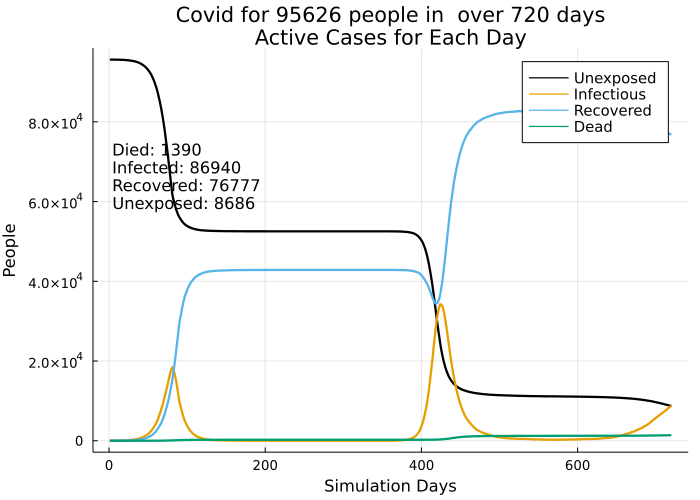

In [40]:
cumplot(series, locale)

Note that the orange line labeled Infectious, which shows the current number of infected people, is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: Some people got sick today. Some people get better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. Newspaper tracking shows the new active infections of each day--who got sick today? The next day, if no one new got sick the line would be at zero--even though the people who got sick aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. This is the least common way to show the data.

In [ ]:
cumplot(series, locale, [:nil, :mild, :sick, :severe])

In [ ]:
newplot(series, locale)

In [ ]:
cumplot(series, locale, [:base, :omicron])

In [ ]:
colmap = series[locale].cols

In [ ]:
series[locale].cum[end, colmap[:omicron]]

In [ ]:
series[locale].cum[end, colmap[:base]]

In [ ]:
(cs.vaxlist, cs.variantlist)

In [ ]:
keys(model)

In [ ]:
keys(popdat)

In [ ]:
keys(series)

In [ ]:
model.dat

In [ ]:
popdat[locale]

In [ ]:
locdat = popdat[locale]
countmap(locdat.cond)

In [ ]:
countmap(locdat.status)

In [ ]:
countmap(locdat.variant)

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
fieldnames(typeof(series[locale]))

In [ ]:
map2series = series[locale].cols

In [ ]:
println(":cum ", typeof(series[locale].cum))
println(":cum ", size(series[locale].cum))
println(":new ", size(series[locale].new))

In [ ]:
series[locale].new[:, map2series[:infectious]]

## Test a social distancing case

In [ ]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

In [ ]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

In [ ]:
result_dict, series = run_a_sim(ndays, locale, showr0=false, silent=true, runcases=[seed_1_6, sd1, sd1_end]);

In [ ]:
virus_outcome(series, locale, base=:pop)

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale,[:infectious, :dead])

In [ ]:
outdat = result_dict.dat["popdat"][locale]
all(outdat.sdcomply .== :none)

## Social distancing only among those age40_59, age60_79, age80_plus

In [ ]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
popdat, series = runsim(model; 
                    runcases=[seed_1_6, sdolder, sdolder_end]);

In [ ]:
olderdat =popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [ ]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

In [ ]:
popdat, series = runsim(model,
    runcases=[seed_1_6, sd1, sdyoung_end]);

In [ ]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [ ]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

In [ ]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

In [ ]:
typeof(mixdat.agegrp)

In [ ]:
mixdat = popdat[locale]

In [ ]:
cumplot(series, locale, [:infectious, :dead])

In [ ]:
@Select(status, agegrp, cond, sdcomply)(locdat)